# EUKLEMS Growth Accounts Dataset - Exploratory Data Analysis

**Research Objectives**
1. Construct industry-level productivity time series
2. Build inter-industry productivity co-movement networks
3. Overlay AI/software intensity measures
4. Perform dynamic (pre/post 2015) comparison

## Environment Setup

The analysis requires standard data science libraries for data manipulation, statistical analysis, and visualization. Display options are configured to facilitate comprehensive data inspection.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Loading

The EUKLEMS Growth Accounts dataset provides industry-level productivity measures across multiple countries and years. Initial examination of dataset structure and dimensions is necessary to understand the available variables.

In [4]:
data_path = Path('data/growth accounts.csv')
df = pd.read_csv(data_path)

print(f"Shape: {df.shape}")
print(f"\nColumn structure:")
print(df.dtypes)
print(f"\nSample observations:")
df.head(10)

Shape: (2467044, 8)

Column structure:
Unnamed: 0        int64
nace_r2_code     object
geo_code         object
year              int64
nace_r2_name     object
geo_name         object
var              object
value           float64
dtype: object

Sample observations:


,Unnamed: 0,nace_r2_code,geo_code,year,nace_r2_name,geo_name,var,value
0,4,A,AT,1995,"Agriculture, forestry and fishing",Austria,LAB,3669.5984
1,5,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAP,193.1368
2,37,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAP_QI,97.5399
3,38,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPICT_QI,29.3106
4,39,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPNICT_QI,99.2779
5,40,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPTang_QI,98.3084
6,43,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPIntang_QI,80.9829
7,44,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPEconComp_QI,246.7640
8,45,A,AT,1995,"Agriculture, forestry and fishing",Austria,CAPInnovprop_QI,51.2492
9,46,A,AT,1995,"Agriculture, forestry and fishing",Austria,LAB_QI,150.1402


## Dataset Structure Analysis

### Dimensional Analysis

Examining the dataset dimensions (countries, industries, years, variables) provides insight into coverage and potential panel balance. Understanding the temporal range is critical for assessing feasibility of time series analysis.

### Unique Values Inventory

A comprehensive inventory of unique values across key dimensions establishes the scope of available data for analysis.

In [5]:
print(f"Total observations: {len(df):,}")
print(f"Columns: {list(df.columns)}")

print(f"\nDimensional coverage:")
print(f"  Countries: {df['geo_code'].nunique()}")
print(f"  Industries: {df['nace_r2_code'].nunique()}")
print(f"  Years: {df['year'].nunique()} (range: {df['year'].min()}-{df['year'].max()})")
print(f"  Variables: {df['var'].nunique()}")

print(f"\nData completeness:")
print(f"  Missing values in 'value' column: {df['value'].isnull().sum()} ({df['value'].isnull().sum() / len(df) * 100:.2f}%)")

Total observations: 2,467,044
Columns: ['Unnamed: 0', 'nace_r2_code', 'geo_code', 'year', 'nace_r2_name', 'geo_name', 'var', 'value']

Dimensional coverage:
  Countries: 34
  Industries: 58
  Years: 27 (range: 1995-2021)
  Variables: 68

Data completeness:
  Missing values in 'value' column: 1001825 (40.61%)


In [ ]:
print(f"Countries ({df['geo_code'].nunique()}):")
print(sorted(df['geo_code'].unique()))

print(f"\nIndustries ({df['nace_r2_code'].nunique()}):")
print(sorted(df['nace_r2_code'].unique()))

print(f"\nYears ({df['year'].nunique()}):")
print(sorted(df['year'].unique()))

print(f"\nVariables ({df['var'].nunique()}):")
vars_list = sorted(df['var'].unique())
for i, v in enumerate(vars_list, 1):
    print(f"{i:3d}. {v}")
    if i >= 50:
        print(f"     ... and {len(vars_list) - 50} more")
        break

UNIQUE VALUES

Countries (34): 
['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'EU11', 'EU12', 'EU27', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'JP', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK', 'US']


Industries (58): 
['A', 'B', 'C', 'C10-C12', 'C13-C15', 'C16-C18', 'C19', 'C20', 'C20-C21', 'C21', 'C22-C23', 'C24-C25', 'C26', 'C26-C27', 'C27', 'C28', 'C29-C30', 'C31-C33', 'D', 'D-E', 'E', 'F', 'G', 'G45', 'G46', 'G47', 'H', 'H49', 'H50', 'H51', 'H52', 'H53', 'I', 'J', 'J58-J60', 'J61', 'J62-J63', 'K', 'L', 'L68A', 'M', 'M-N', 'MARKT', 'MARKTxAG', 'N', 'O', 'O-Q', 'P', 'Q', 'Q86', 'Q87-Q88', 'R', 'R-S', 'S', 'T', 'TOT', 'TOT_IND', 'U']


Years (27): 
[np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), n

### Panel Balance Assessment

Panel datasets may exhibit imbalance when not all combinations of dimensions are observed. Assessing the degree of balance informs subsequent modeling decisions.

In [ ]:
n_countries = df['geo_code'].nunique()
n_industries = df['nace_r2_code'].nunique()
n_years = df['year'].nunique()
n_vars = df['var'].nunique()

theoretical_max = n_countries * n_industries * n_years * n_vars

print(f"Theoretical maximum observations: {theoretical_max:,}")
print(f"  ({n_countries} countries × {n_industries} industries × {n_years} years × {n_vars} variables)")
print(f"\nActual observations: {len(df):,}")
print(f"Coverage: {len(df) / theoretical_max * 100:.2f}%")

unique_combo_ciy = df.groupby(['geo_code', 'nace_r2_code', 'year']).size()
print(f"\nUnique Country×Industry×Year combinations: {len(unique_combo_ciy):,}")
print(f"Average variables per combination: {unique_combo_ciy.mean():.2f}")
print(f"Combinations with all {n_vars} variables: {(unique_combo_ciy == n_vars).sum():,}")

PANEL BALANCE CHECK

Theoretical maximum observations: 3,620,592
  (34 countries × 58 industries × 27 years × 68 variables)

Actual observations: 2,467,044
Coverage: 68.14%

--------------------------------------------------------------------------------
OBSERVATIONS PER DIMENSION
--------------------------------------------------------------------------------

Unique Country×Industry×Year combinations: 53,244
Average variables per combination: 46.33
Median variables per combination: 46.00

Combinations with all 68 variables: 810


## Variable Availability Analysis

The research design requires specific productivity measures (TFP, labor productivity) and technology intensity proxies (software capital, ICT capital, intangibles). Assessing availability and quality of these variables determines analytical feasibility.

### Key Variables for Research Design

In [6]:
key_variables = {
    'Productivity': ['VAConTFP', 'VATFP_I', 'LP1_G', 'LP2_G', 'LP1ConTFP', 'LP2ConTFP'],
    'Software': ['VACon_Soft_DB', 'LP1Con_Soft_DB', 'LP2Con_Soft_DB'],
    'ICT Capital': ['CAPTangICT_QI'],
    'Intangibles': ['CAPIntang_QI', 'CAPInnovprop_QI']
}

all_key_vars = [v for vars_list in key_variables.values() for v in vars_list]
available_vars = df['var'].unique()

print("Variable availability by category:\n")
for category, vars_list in key_variables.items():
    print(f"{category}:")
    for var in vars_list:
        status = "Available" if var in available_vars else "Missing"
        print(f"  {var}: {status}")
    print()

key_var_stats = []
for var in all_key_vars:
    if var in available_vars:
        var_data = df[df['var'] == var]
        stats = {
            'Variable': var,
            'Total Obs': len(var_data),
            'Non-null': var_data['value'].notna().sum(),
            'Missing %': f"{var_data['value'].isna().sum() / len(var_data) * 100:.2f}%",
            'Countries': var_data['geo_code'].nunique(),
            'Industries': var_data['nace_r2_code'].nunique(),
            'Years': var_data['year'].nunique(),
            'Year Range': f"{var_data['year'].min()}-{var_data['year'].max()}"
        }
        key_var_stats.append(stats)

key_var_df = pd.DataFrame(key_var_stats)
key_var_df

Variable availability by category:

Productivity:
  VAConTFP: Available
  VATFP_I: Available
  LP1_G: Available
  LP2_G: Available
  LP1ConTFP: Available
  LP2ConTFP: Available

Software:
  VACon_Soft_DB: Available
  LP1Con_Soft_DB: Available
  LP2Con_Soft_DB: Available

ICT Capital:
  CAPTangICT_QI: Missing

Intangibles:
  CAPIntang_QI: Available
  CAPInnovprop_QI: Available



,Variable,Total Obs,Non-null,Missing %,Countries,Industries,Years,Year Range
0,VAConTFP,53244,19917,62.59%,34,58,27,1995-2021
1,VATFP_I,53244,21760,59.13%,34,58,27,1995-2021
2,LP1_G,53244,39158,26.46%,34,58,27,1995-2021
3,LP2_G,53244,41467,22.12%,34,58,27,1995-2021
4,LP1ConTFP,53244,19917,62.59%,34,58,27,1995-2021
5,LP2ConTFP,53244,19917,62.59%,34,58,27,1995-2021
6,VACon_Soft_DB,53244,22160,58.38%,34,58,27,1995-2021
7,LP1Con_Soft_DB,53244,22160,58.38%,34,58,27,1995-2021
8,LP2Con_Soft_DB,53244,22160,58.38%,34,58,27,1995-2021
9,CAPIntang_QI,53244,40513,23.91%,34,58,27,1995-2021


### Distribution Characteristics

Examining distributions of productivity variables identifies potential outliers and assesses data quality. Histograms provide visual inspection of central tendency and dispersion.

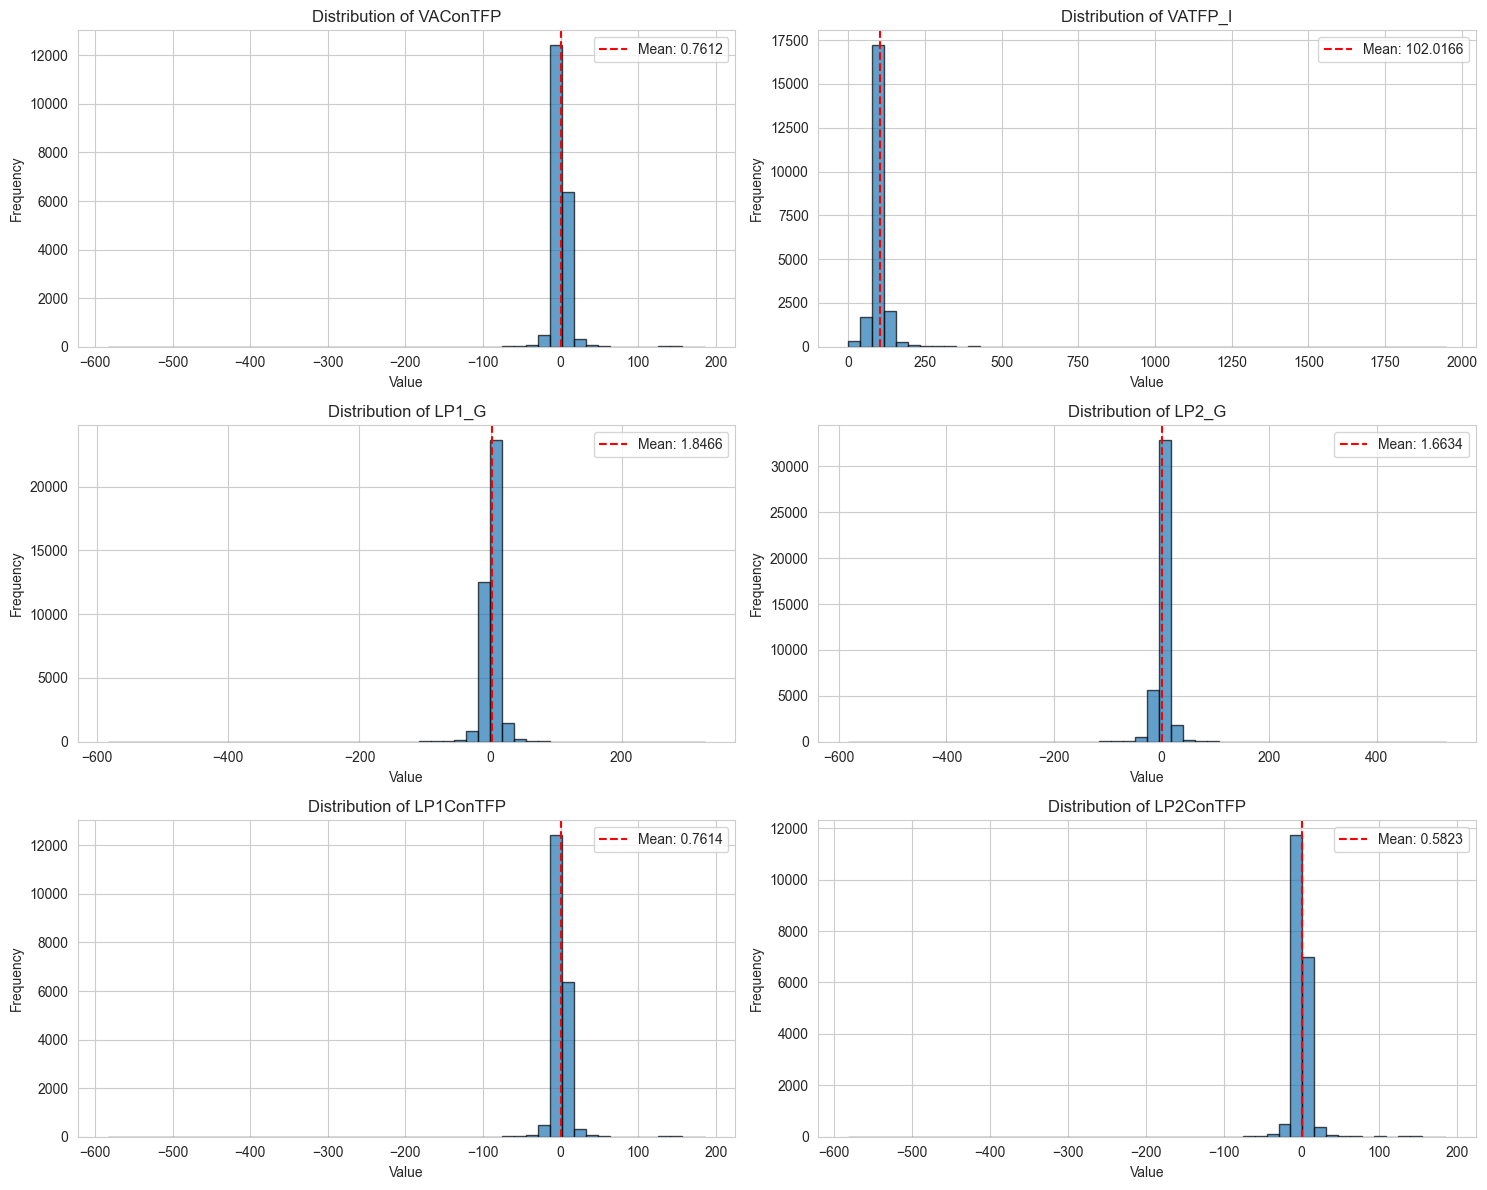

In [ ]:
productivity_vars = [v for v in key_variables['Productivity'] if v in available_vars]

if productivity_vars:
    n_vars = len(productivity_vars)
    fig, axes = plt.subplots((n_vars + 1) // 2, 2, figsize=(15, 4 * ((n_vars + 1) // 2)))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for i, var in enumerate(productivity_vars):
        var_data = df[df['var'] == var]['value'].dropna()
        if len(var_data) > 0:
            axes[i].hist(var_data, bins=50, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Distribution of {var}')
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
            axes[i].axvline(var_data.mean(), color='red', linestyle='--', label=f'Mean: {var_data.mean():.4f}')
            axes[i].legend()
    
    for i in range(len(productivity_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No productivity variables found in dataset")

## Time Series Suitability Analysis

Effective time series analysis requires sufficient temporal span and continuity. The presence of consecutive years within country-industry pairs determines the viability of dynamic modeling approaches.

### Temporal Coverage and Continuity

In [7]:
tfp_var = 'VAConTFP' if 'VAConTFP' in available_vars else (
    'VATFP_I' if 'VATFP_I' in available_vars else None
)

if tfp_var:
    print(f"Analyzing: {tfp_var}\n")
    tfp_data = df[df['var'] == tfp_var].copy()
    
    years_per_combo = tfp_data.groupby(['geo_code', 'nace_r2_code'])['year'].agg([
        ('count', 'count'),
        ('min_year', 'min'),
        ('max_year', 'max'),
        ('span', lambda x: x.max() - x.min() + 1)
    ]).reset_index()
    
    print(f"Years per Country-Industry combination:")
    print(f"  Mean: {years_per_combo['count'].mean():.2f}")
    print(f"  Median: {years_per_combo['count'].median():.2f}")
    print(f"  Range: [{years_per_combo['count'].min()}, {years_per_combo['count'].max()}]")
    
    def check_consecutive(group):
        years = sorted(group['year'].values)
        if len(years) < 2:
            return 0
        max_consecutive = 1
        current_consecutive = 1
        for i in range(1, len(years)):
            if years[i] == years[i-1] + 1:
                current_consecutive += 1
                max_consecutive = max(max_consecutive, current_consecutive)
            else:
                current_consecutive = 1
        return max_consecutive
    
    consecutive_years = tfp_data.groupby(['geo_code', 'nace_r2_code']).apply(
        check_consecutive
    ).reset_index(name='max_consecutive')
    
    print(f"\nConsecutive years analysis:")
    print(f"  Combinations with ≥10 consecutive years: {(consecutive_years['max_consecutive'] >= 10).sum()}")
    print(f"  Combinations with ≥15 consecutive years: {(consecutive_years['max_consecutive'] >= 15).sum()}")
    print(f"  Combinations with ≥20 consecutive years: {(consecutive_years['max_consecutive'] >= 20).sum()}")
else:
    print("No TFP variables available")

Analyzing: VAConTFP

Years per Country-Industry combination:
  Mean: 27.00
  Median: 27.00
  Range: [27, 27]

Consecutive years analysis:
  Combinations with ≥10 consecutive years: 1972
  Combinations with ≥15 consecutive years: 1972
  Combinations with ≥20 consecutive years: 1972


### Structural Break Assessment (2015)

The year 2015 serves as a potential structural break point for AI-related technological diffusion. Assessing data availability before and after this threshold determines feasibility of dynamic comparison.

STRUCTURAL BREAK ANALYSIS (2015)

Observations before 2015: 39,440
Observations in/after 2015: 13,804

Country-Industry combinations with data:
  Before 2015: 1972
  After 2015: 1972
  In both periods: 1972

AGGREGATE TFP TIME SERIES

Top 10 countries by data points:
geo_code
AT    1566
BE    1566
BG    1566
CY    1566
CZ    1566
DE    1566
DK    1566
EE    1566
EL    1566
ES    1566
dtype: int64


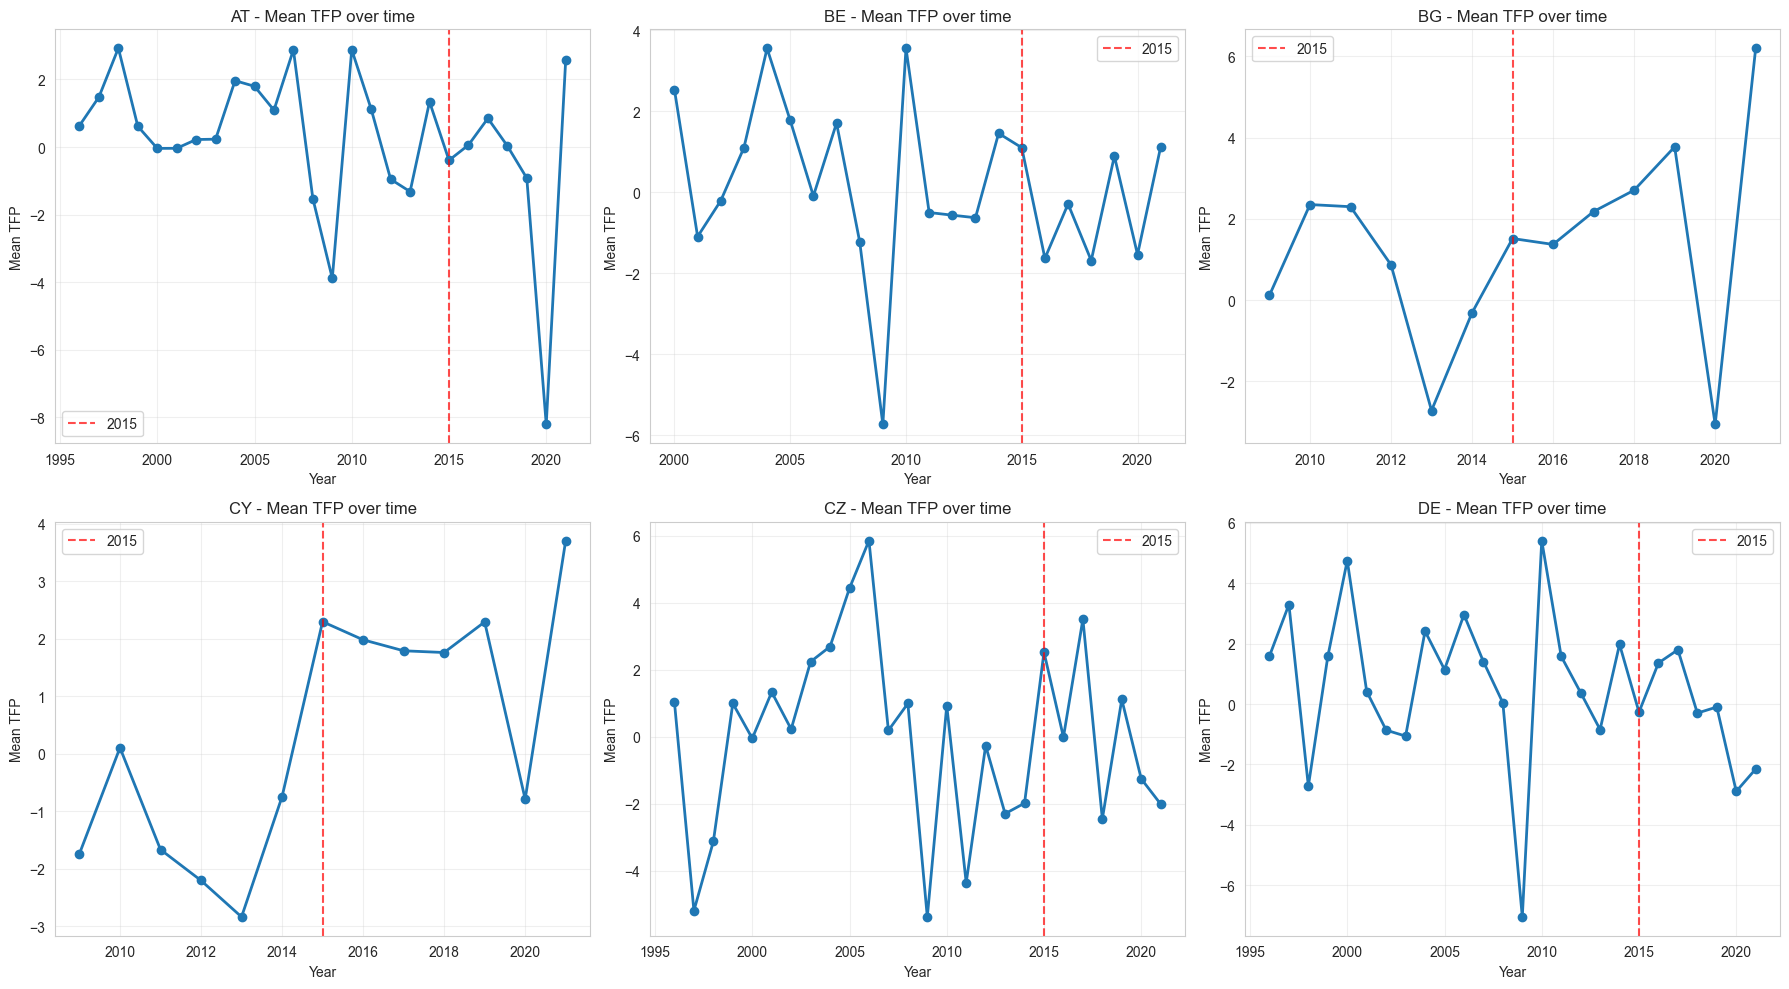

In [ ]:
if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    
    pre_2015 = tfp_data[tfp_data['year'] < 2015]
    post_2015 = tfp_data[tfp_data['year'] >= 2015]
    
    print(f"Observations before 2015: {len(pre_2015):,}")
    print(f"Observations in/after 2015: {len(post_2015):,}")
    
    pre_2015_combos = pre_2015.groupby(['geo_code', 'nace_r2_code']).size()
    post_2015_combos = post_2015.groupby(['geo_code', 'nace_r2_code']).size()
    
    print(f"\nCountry-Industry combinations with data:")
    print(f"  Before 2015: {len(pre_2015_combos)}")
    print(f"  After 2015: {len(post_2015_combos)}")
    print(f"  In both periods: {len(set(pre_2015_combos.index) & set(post_2015_combos.index))}")
    
    country_coverage = tfp_data.groupby('geo_code').size().sort_values(ascending=False)
    top_countries = country_coverage.head(6).index
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, country in enumerate(top_countries):
        country_data = tfp_data[tfp_data['geo_code'] == country].groupby('year')['value'].mean()
        axes[i].plot(country_data.index, country_data.values, marker='o', linewidth=2)
        axes[i].axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='2015')
        axes[i].set_title(f'{country} - Mean TFP over time')
        axes[i].set_xlabel('Year')
        axes[i].set_ylabel('Mean TFP')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No TFP variable available for time series analysis")

## Industry Resolution Analysis

Industry codes follow the NACE Rev. 2 classification system. Understanding the level of aggregation and temporal stability of industry coverage is essential for network construction.

### Industry Classification Structure

In [ ]:
industries = sorted(df['nace_r2_code'].unique())
print(f"Total unique industries: {len(industries)}\n")
for i, ind in enumerate(industries, 1):
    print(f"  {i:3d}. {ind}")

code_lengths = df['nace_r2_code'].astype(str).str.len()
print(f"\nCode length distribution:")
print(code_lengths.value_counts().sort_index())

if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    industries_by_year = tfp_data.groupby('year')['nace_r2_code'].nunique()
    
    print(f"\nTemporal stability:")
    print(f"  Mean industries per year: {industries_by_year.mean():.2f}")
    print(f"  Std dev: {industries_by_year.std():.2f}")
    print(f"  Range: [{industries_by_year.min()}, {industries_by_year.max()}]")

INDUSTRY CODE ANALYSIS

Total unique industries: 58

Industry codes:
    1. A
    2. B
    3. C
    4. C10-C12
    5. C13-C15
    6. C16-C18
    7. C19
    8. C20
    9. C20-C21
   10. C21
   11. C22-C23
   12. C24-C25
   13. C26
   14. C26-C27
   15. C27
   16. C28
   17. C29-C30
   18. C31-C33
   19. D
   20. D-E
   21. E
   22. F
   23. G
   24. G45
   25. G46
   26. G47
   27. H
   28. H49
   29. H50
   30. H51
   31. H52
   32. H53
   33. I
   34. J
   35. J58-J60
   36. J61
   37. J62-J63
   38. K
   39. L
   40. L68A
   41. M
   42. M-N
   43. MARKT
   44. MARKTxAG
   45. N
   46. O
   47. O-Q
   48. P
   49. Q
   50. Q86
   51. Q87-Q88
   52. R
   53. R-S
   54. S
   55. T
   56. TOT
   57. TOT_IND
   58. U

--------------------------------------------------------------------------------
INDUSTRY CODE STRUCTURE
--------------------------------------------------------------------------------

Code length distribution:
nace_r2_code
1    886788
3    895698
4     42228
5     42228


### Industry Data Coverage

Identifying industries with sparse observations prevents inclusion of unreliable series in network analysis. Adequate coverage across countries and years ensures robustness of correlation estimates.

In [ ]:
if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    
    obs_per_industry = tfp_data.groupby('nace_r2_code').size().sort_values(ascending=False)
    
    industry_coverage = tfp_data.groupby('nace_r2_code').agg({
        'geo_code': 'nunique',
        'year': ['nunique', 'min', 'max'],
        'value': 'count'
    }).round(2)
    industry_coverage.columns = ['Countries', 'Years', 'Min Year', 'Max Year', 'Observations']
    
    print("Industry data coverage:")
    print(industry_coverage)
    
    suitable = industry_coverage[(industry_coverage['Countries'] >= 5) & (industry_coverage['Years'] >= 10)]
    print(f"\nIndustries suitable for network analysis (≥5 countries, ≥10 years): {len(suitable)}")
    if len(suitable) > 0:
        print(f"Industries: {list(suitable.index)}")
else:
    print("No TFP variable available for industry analysis")

SPARSE INDUSTRY IDENTIFICATION

Observations per industry (all countries):
nace_r2_code
A           918
B           918
C           918
C10-C12     918
C13-C15     918
C16-C18     918
C19         918
C20         918
C20-C21     918
C21         918
C22-C23     918
C24-C25     918
C26         918
C26-C27     918
C27         918
C28         918
C29-C30     918
C31-C33     918
D           918
D-E         918
E           918
F           918
G           918
G45         918
G46         918
G47         918
H           918
H49         918
H50         918
H51         918
H52         918
H53         918
I           918
J           918
J58-J60     918
J61         918
J62-J63     918
K           918
L           918
L68A        918
M           918
M-N         918
MARKT       918
MARKTxAG    918
N           918
O           918
O-Q         918
P           918
Q           918
Q86         918
Q87-Q88     918
R           918
R-S         918
S           918
T           918
TOT         918
TOT_IND     918


## AI Intensity Feasibility Analysis

Software capital contribution and ICT capital stock serve as proxies for technological intensity. Cross-industry variation in these measures enables classification of high versus low technology-intensity sectors.

### Software and ICT Capital as Intensity Proxies

In [ ]:
software_vars = [v for v in key_variables['Software'] + key_variables['ICT Capital'] 
                 if v in available_vars]

if software_vars:
    for var in software_vars:
        print(f"Variable: {var}")
        print("=" * 40)
        
        var_data = df[df['var'] == var].copy()
        
        print(f"Availability:")
        print(f"  Total observations: {len(var_data):,}")
        print(f"  Non-null values: {var_data['value'].notna().sum():,}")
        print(f"  Countries: {var_data['geo_code'].nunique()}")
        print(f"  Industries: {var_data['nace_r2_code'].nunique()}")
        print(f"  Year range: {var_data['year'].min()}-{var_data['year'].max()}")
        
        var_values = var_data['value'].dropna()
        if len(var_values) > 0:
            print(f"\nDistribution:")
            print(f"  Mean: {var_values.mean():.4f}")
            print(f"  Std: {var_values.std():.4f}")
            cv = var_values.std() / var_values.mean() if var_values.mean() != 0 else np.nan
            print(f"  CV (std/mean): {cv:.4f}" if not np.isnan(cv) else "  CV: N/A")
            print(f"  Range: [{var_values.min():.4f}, {var_values.max():.4f}]")
            
            unique_values = var_values.nunique()
            print(f"  Unique values: {unique_values}")
            
            industry_means = var_data.groupby('nace_r2_code')['value'].mean().dropna()
            if len(industry_means) > 0:
                print(f"\nVariance across industries:")
                print(f"  Industries with data: {len(industry_means)}")
                print(f"  Mean: {industry_means.mean():.4f}")
                print(f"  Std: {industry_means.std():.4f}")
                print(f"  Range: [{industry_means.min():.4f}, {industry_means.max():.4f}]")
        print()
else:
    print("No software/ICT variables available in dataset")

AI/SOFTWARE INTENSITY PROXY ANALYSIS

Variable: VACon_Soft_DB

Availability:
  Total observations: 53,244
  Non-null values: 22,160
  Countries: 34
  Industries: 58
  Year range: 1995-2021

Distribution:
  Mean: 0.1604
  Std: 0.4702
  CV (std/mean): 2.9309
  Min: -16.0311
  Max: 17.5032
  Unique values: 22152

Variance across industries:
  Industries with data: 55
  Mean across industries: 0.1594
  Std across industries: 0.1739
  Range: [0.0127, 0.9828]

Variable: LP1Con_Soft_DB

Availability:
  Total observations: 53,244
  Non-null values: 22,160
  Countries: 34
  Industries: 58
  Year range: 1995-2021

Distribution:
  Mean: 0.1536
  Std: 0.4791
  CV (std/mean): 3.1198
  Min: -15.7815
  Max: 17.0876
  Unique values: 22159

Variance across industries:
  Industries with data: 55
  Mean across industries: 0.1548
  Std across industries: 0.1440
  Range: [0.0158, 0.6913]

Variable: LP2Con_Soft_DB

Availability:
  Total observations: 53,244
  Non-null values: 22,160
  Countries: 34
  Indust

### High-Intensity Industry Identification

Industries are ranked by average software/ICT intensity. The upper quartile defines high-intensity sectors for subsequent network stratification.

HIGH-INTENSITY INDUSTRIES

Using VACon_Soft_DB as intensity proxy

Industry ranking by average VACon_Soft_DB:
               mean    std  count
nace_r2_code                     
J62-J63      0.9828 1.1225    386
J            0.6473 0.8050    500
J61          0.6180 1.4155    361
K            0.4882 0.6119    500
J58-J60      0.4785 1.2390    411
M            0.2329 0.2680    475
G46          0.2264 0.2093    213
C26          0.2212 0.7130    386
H53          0.2165 1.2761    161
H52          0.2102 0.6240    188
M-N          0.2037 0.2306    500
C26-C27      0.2024 0.6408    361
D            0.1875 0.3219    475
D-E          0.1714 0.2512    475
MARKTxAG     0.1633 0.1374    475
C19          0.1568 0.9119    386
C28          0.1554 0.1787    386
G47          0.1505 0.1547    211
C27          0.1498 0.3926    386
MARKT        0.1493 0.1265    500
N            0.1484 0.3361    475
C29-C30      0.1465 0.2377    386
G            0.1413 0.1452    500
C21          0.1302 0.2536    311
TOT   

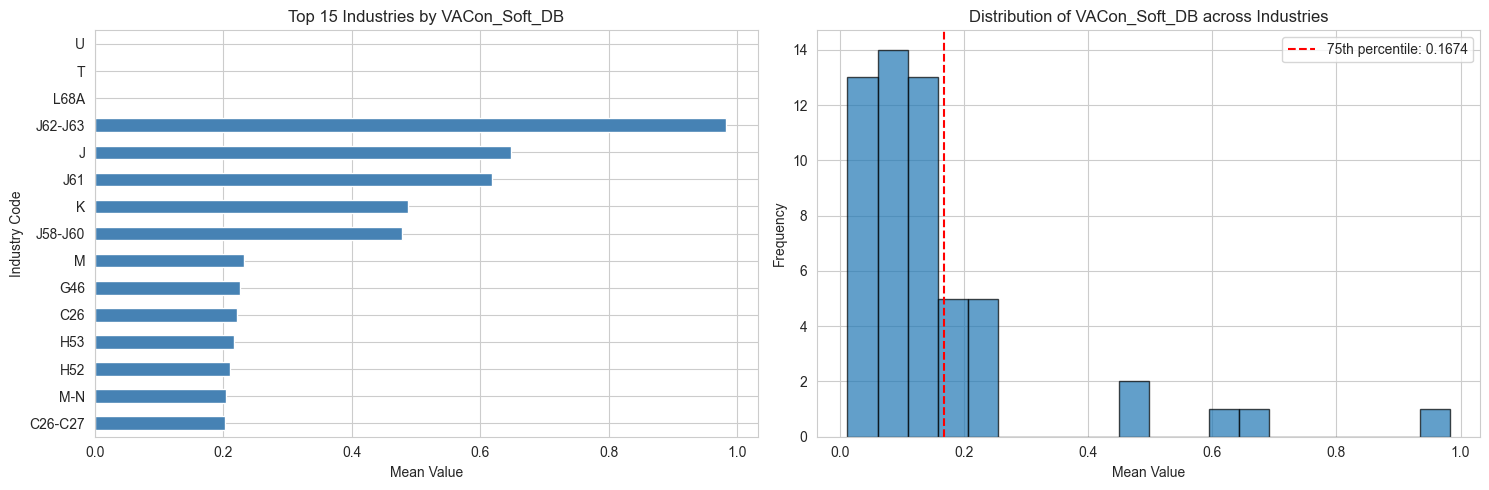

In [ ]:
if software_vars:
    proxy_var = software_vars[0]
    print(f"Using {proxy_var} as intensity proxy\n")
    
    proxy_data = df[df['var'] == proxy_var].copy()
    
    industry_intensity = proxy_data.groupby('nace_r2_code')['value'].agg([
        'mean', 'std', 'count'
    ]).sort_values('mean', ascending=False)
    
    print(f"Industry ranking by average {proxy_var}:")
    print(industry_intensity)
    
    if len(industry_intensity) > 0:
        threshold = industry_intensity['mean'].quantile(0.75)
        high_intensity = industry_intensity[industry_intensity['mean'] >= threshold]
        
        print(f"\nHigh-intensity industries (top 25%, threshold={threshold:.4f}):")
        for ind in high_intensity.index:
            print(f"  {ind}: mean={high_intensity.loc[ind, 'mean']:.4f}, "
                  f"std={high_intensity.loc[ind, 'std']:.4f}, "
                  f"n={int(high_intensity.loc[ind, 'count'])}")
    
    if len(industry_intensity) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        industry_intensity.sort_values('mean', ascending=True).tail(15)['mean'].plot(
            kind='barh', ax=axes[0], color='steelblue'
        )
        axes[0].set_title(f'Top 15 Industries by {proxy_var}')
        axes[0].set_xlabel('Mean Value')
        axes[0].set_ylabel('Industry Code')
        
        axes[1].hist(industry_intensity['mean'].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[1].axvline(threshold, color='red', linestyle='--', label=f'75th percentile: {threshold:.4f}')
        axes[1].set_title(f'Distribution of {proxy_var} across Industries')
        axes[1].set_xlabel('Mean Value')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("No software/ICT variables available for intensity analysis")

## Cross-Industry Correlation Analysis

Constructing productivity co-movement networks requires meaningful correlation structure across industries. Correlation matrices are computed for countries with adequate data coverage.

### Network Feasibility Assessment

In [ ]:
if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    
    country_data_counts = tfp_data.groupby('geo_code').size().sort_values(ascending=False)
    top_countries = country_data_counts.head(3).index.tolist()
    
    for country in top_countries:
        print(f"Country: {country}")
        print("=" * 40)
        
        country_tfp = tfp_data[tfp_data['geo_code'] == country].copy()
        
        pivot_tfp = country_tfp.pivot_table(
            index='year', 
            columns='nace_r2_code', 
            values='value'
        )
        
        print(f"Pivot table shape: {pivot_tfp.shape}")
        print(f"Missing data: {pivot_tfp.isnull().sum().sum()} / {pivot_tfp.size} "
              f"({pivot_tfp.isnull().sum().sum() / pivot_tfp.size * 100:.2f}%)")
        
        min_obs = int(0.5 * len(pivot_tfp))
        pivot_tfp_clean = pivot_tfp.dropna(axis=1, thresh=min_obs)
        
        print(f"After filtering (≥{min_obs} observations): {pivot_tfp_clean.shape[1]} industries")
        
        if pivot_tfp_clean.shape[1] >= 3:
            corr_matrix = pivot_tfp_clean.corr()
            
            mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
            upper_triangle = corr_matrix.where(mask)
            correlations = upper_triangle.stack()
            
            print(f"\nCorrelation statistics:")
            print(f"  Number of pairwise correlations: {len(correlations)}")
            print(f"  Mean correlation: {correlations.mean():.4f}")
            print(f"  Std correlation: {correlations.std():.4f}")
            print(f"  Range: [{correlations.min():.4f}, {correlations.max():.4f}]")
            
            meaningful_correlations = ((correlations.abs() >= 0.2) & (correlations.abs() < 0.99)).sum()
            print(f"\nMeaningful correlations (0.2 ≤ |corr| < 0.99): {meaningful_correlations} "
                  f"({meaningful_correlations / len(correlations) * 100:.1f}%)")
        else:
            print(f"Insufficient industries for correlation analysis")
        print()
        
        if country == top_countries[0] and pivot_tfp_clean.shape[1] >= 3:
            break
else:
    print("No TFP variable available for correlation analysis")

CROSS-INDUSTRY CORRELATION ANALYSIS

Countries by data availability:
geo_code
AT    1566
BE    1566
BG    1566
CY    1566
CZ    1566
DE    1566
DK    1566
EE    1566
EL    1566
ES    1566
dtype: int64

COUNTRY: AT

Pivot table shape: (26, 54)
Years: 26
Industries: 54
Missing data: 0 / 1404 (0.00%)

After filtering (≥13 observations): 54 industries

--------------------------------------------------------------------------------
CORRELATION STATISTICS
--------------------------------------------------------------------------------
Number of pairwise correlations: 1431
Mean correlation: 0.0927
Std correlation: 0.2757
Min correlation: -0.5928
Max correlation: 1.0000

Correlation distribution:
  [-1.0, -0.5): 7 (0.5%)
  [-0.5, -0.2): 202 (14.1%)
  [-0.2,  0.2): 745 (52.1%)
  [ 0.2,  0.5): 366 (25.6%)
  [ 0.5,  1.0]: 111 (7.8%)

✓ Meaningful correlations (0.2 ≤ |corr| < 0.99): 685 (47.9%)
  ✓ Correlation structure appears suitable for network analysis


### Correlation Heatmap

Visualization of the correlation matrix reveals patterns of productivity co-movement. Strongly correlated industry pairs indicate potential supply chain or technological linkages.

Plotting correlation heatmap for AT


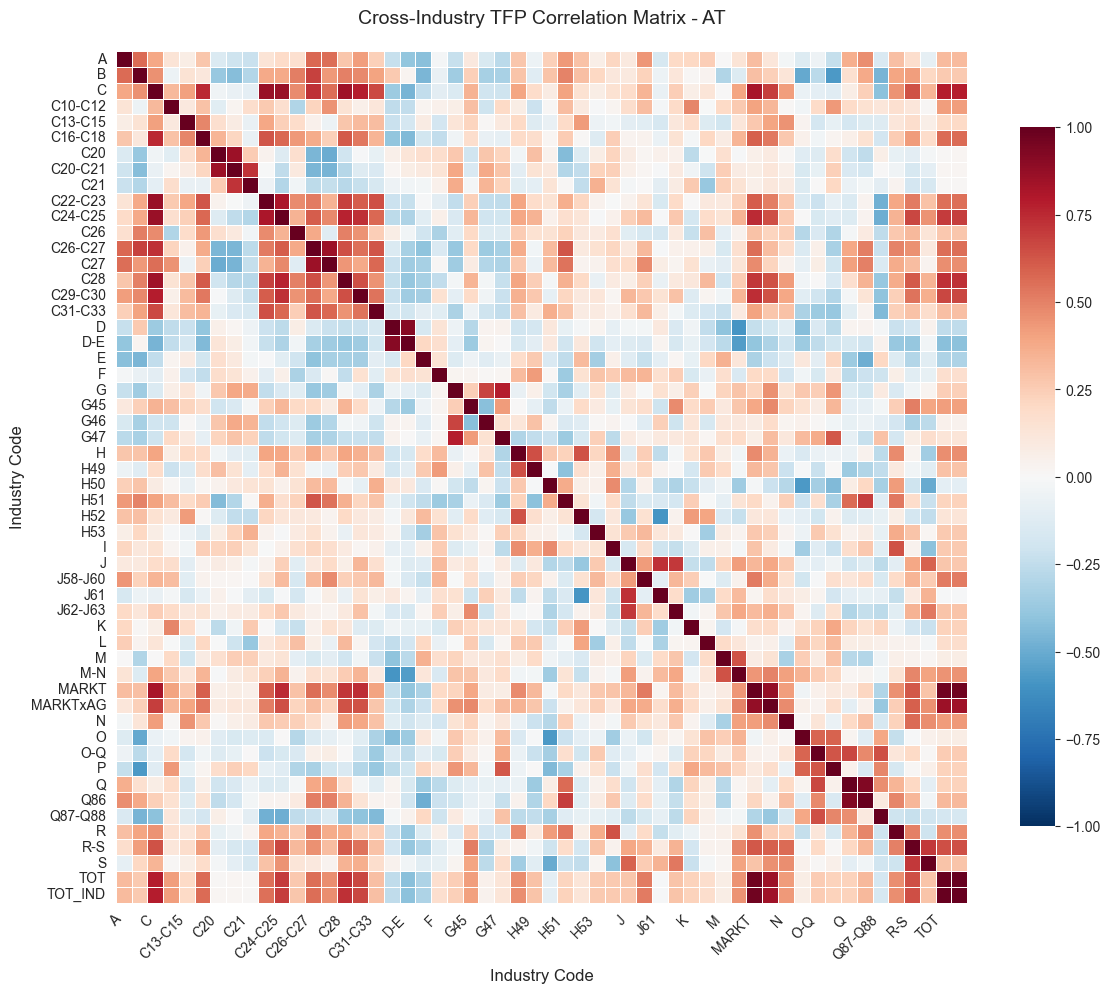


NETWORK STRUCTURE INSIGHTS

Top 10 most correlated industry pairs:
  TOT - TOT_IND: 1.0000
  MARKT - TOT_IND: 0.9728
  MARKT - TOT: 0.9725
  Q - Q86: 0.9238
  D - D-E: 0.9104
  MARKT - MARKTxAG: 0.8769
  C - C24-C25: 0.8670
  C - C22-C23: 0.8602
  C26-C27 - C27: 0.8542
  C20 - C20-C21: 0.8522

Top 10 most negatively correlated industry pairs:
  C24-C25 - Q87-Q88: -0.4867
  E - Q86: -0.4913
  C20 - C27: -0.4926
  H50 - S: -0.5030
  B - O: -0.5155
  D-E - M-N: -0.5620
  H50 - O: -0.5709
  B - P: -0.5736
  H52 - J61: -0.5918
  D - M-N: -0.5928


In [ ]:
if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    country_data_counts = tfp_data.groupby('geo_code').size().sort_values(ascending=False)
    top_country = country_data_counts.index[0]
    
    country_tfp = tfp_data[tfp_data['geo_code'] == top_country].copy()
    pivot_tfp = country_tfp.pivot_table(index='year', columns='nace_r2_code', values='value')
    
    min_obs = int(0.5 * len(pivot_tfp))
    pivot_tfp_clean = pivot_tfp.dropna(axis=1, thresh=min_obs)
    
    if pivot_tfp_clean.shape[1] >= 3:
        corr_matrix = pivot_tfp_clean.corr()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True if len(corr_matrix) <= 10 else False, 
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title(f'Cross-Industry TFP Correlation Matrix - {top_country}', fontsize=14, pad=20)
        plt.xlabel('Industry Code', fontsize=12)
        plt.ylabel('Industry Code', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper_triangle = corr_matrix.where(mask)
        correlations = upper_triangle.stack().sort_values(ascending=False)
        
        print(f"Top 10 most correlated industry pairs:")
        for (ind1, ind2), corr in correlations.head(10).items():
            print(f"  {ind1} - {ind2}: {corr:.4f}")
        
        print(f"\nTop 10 most negatively correlated industry pairs:")
        for (ind1, ind2), corr in correlations.tail(10).items():
            print(f"  {ind1} - {ind2}: {corr:.4f}")
    else:
        print(f"Insufficient industries for heatmap")
else:
    print("No TFP variable available")

## Stability and Scaling Analysis

Extreme outliers may result from measurement error or extraordinary economic events. Identifying outliers using interquartile range criteria informs data cleaning decisions.

### Outlier Detection

OUTLIER DETECTION

VAConTFP:
  Normal range: [-18.6956, 19.5818]
  Outliers: 761 / 19917 (3.82%)
  Min outlier: -583.3474
  Max outlier: 186.6053

VATFP_I:
  Normal range: [52.8011, 146.3613]
  Outliers: 1256 / 21760 (5.77%)
  Min outlier: 0.0000
  Max outlier: 1948.0193

LP1_G:
  Normal range: [-24.5276, 28.2800]
  Outliers: 1461 / 39158 (3.73%)
  Min outlier: -583.6685
  Max outlier: 327.8140

LP2_G:
  Normal range: [-25.2691, 28.7291]
  Outliers: 1619 / 41467 (3.90%)
  Min outlier: -582.3972
  Max outlier: 528.4442

LP1ConTFP:
  Normal range: [-18.6918, 19.5789]
  Outliers: 761 / 19917 (3.82%)
  Min outlier: -583.3474
  Max outlier: 186.6053

LP2ConTFP:
  Normal range: [-19.1950, 19.7964]
  Outliers: 799 / 19917 (4.01%)
  Min outlier: -582.1397
  Max outlier: 185.6073

VACon_Soft_DB:
  Normal range: [-0.5058, 0.7029]
  Outliers: 1259 / 22160 (5.68%)
  Min outlier: -16.0311
  Max outlier: 17.5032

LP1Con_Soft_DB:
  Normal range: [-0.5131, 0.7057]
  Outliers: 1281 / 22160 (5.78%)
  Mi

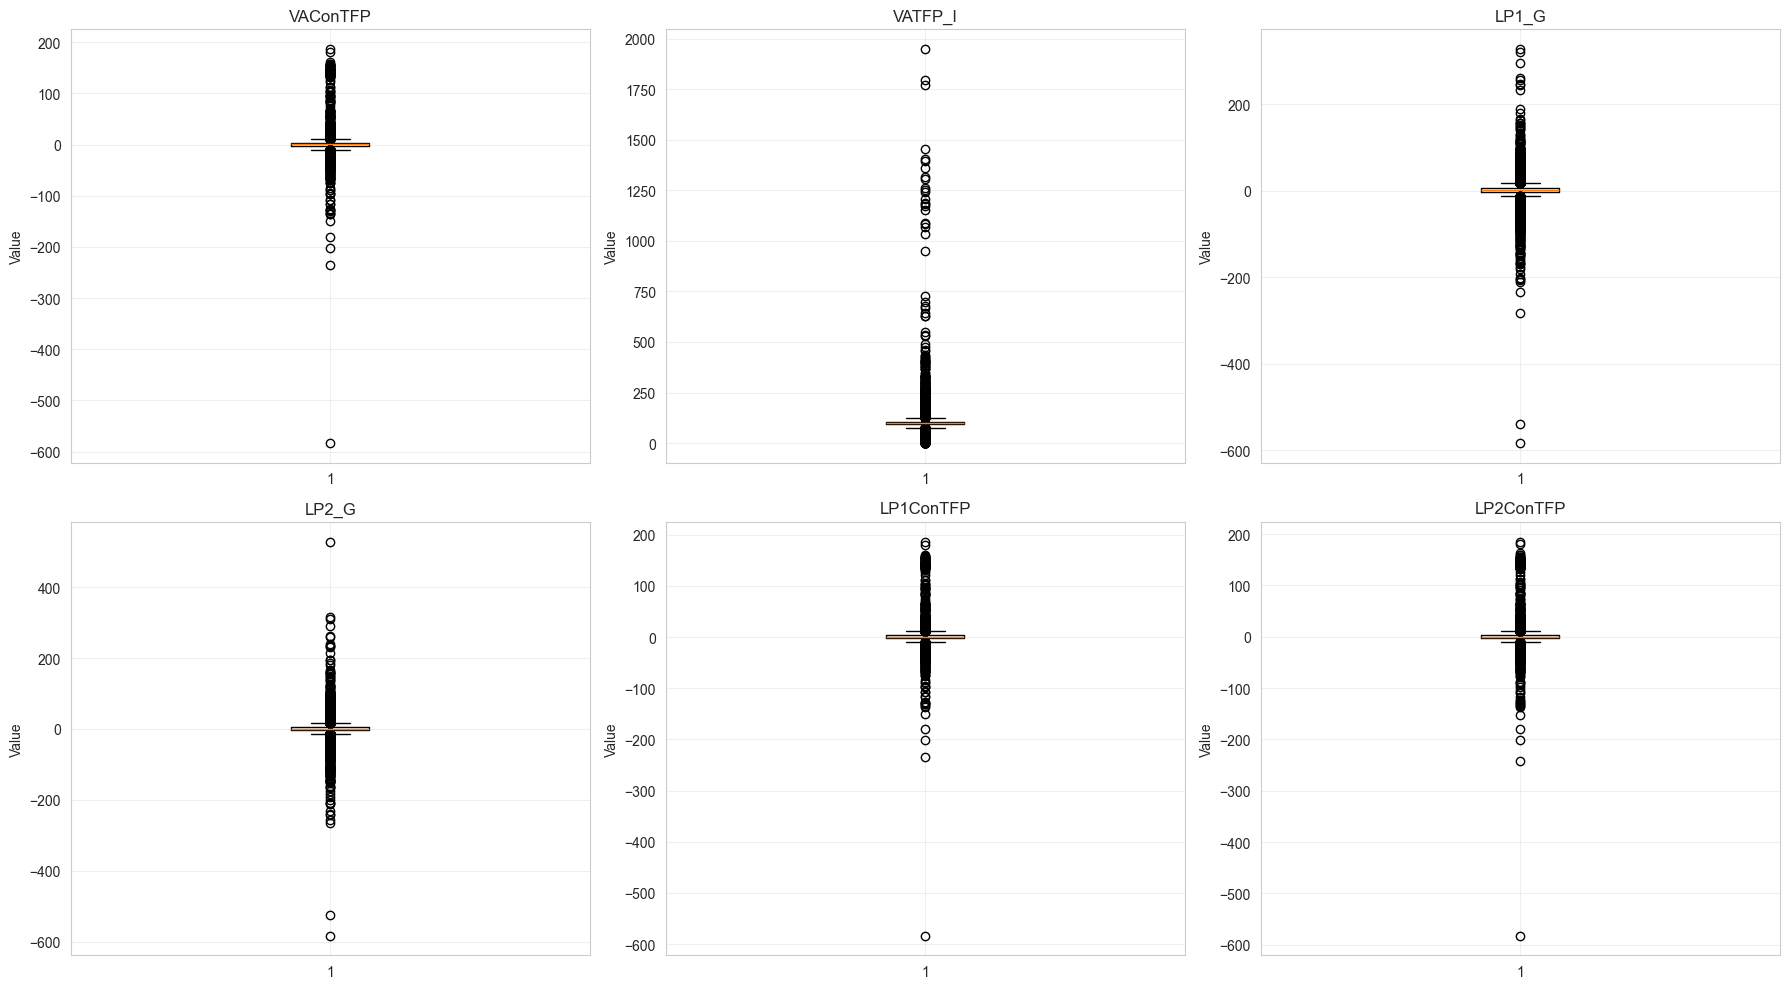

In [ ]:
for var in all_key_vars:
    if var in available_vars:
        var_data = df[df['var'] == var]['value'].dropna()
        
        if len(var_data) > 0:
            Q1 = var_data.quantile(0.25)
            Q3 = var_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            
            outliers = var_data[(var_data < lower_bound) | (var_data > upper_bound)]
            
            print(f"{var}:")
            print(f"  Normal range: [{lower_bound:.4f}, {upper_bound:.4f}]")
            print(f"  Outliers: {len(outliers)} / {len(var_data)} ({len(outliers) / len(var_data) * 100:.2f}%)")
            
            if len(outliers) > 0:
                print(f"  Range of outliers: [{outliers.min():.4f}, {outliers.max():.4f}]")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_idx = 0
for var in all_key_vars[:6]:
    if var in available_vars and plot_idx < 6:
        var_data = df[df['var'] == var]['value'].dropna()
        if len(var_data) > 0:
            axes[plot_idx].boxplot(var_data, vert=True)
            axes[plot_idx].set_title(f'{var}')
            axes[plot_idx].set_ylabel('Value')
            axes[plot_idx].grid(True, alpha=0.3)
            plot_idx += 1

for i in range(plot_idx, 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Temporal Stability

Assessing year-to-year stability of productivity measures identifies structural breaks and evaluates comparability across time periods. Sudden changes in mean or variance may indicate methodological revisions or economic shocks.

TEMPORAL STABILITY CHECK

Yearly statistics for VAConTFP:
        mean     std  count       min      max
year                                          
1995     NaN     NaN      0       NaN      NaN
1996  0.7290  8.3571    633 -132.8191  44.7068
1997  1.2572  8.2836    634  -50.7848  83.8948
1998  0.2520  8.7406    634 -136.0001  84.1330
1999  0.8690  5.7443    634  -23.0710  33.2582
2000  1.8037  8.0113    678  -54.5985  97.1996
2001  1.5126 12.8408    728  -55.7515 141.9662
2002  1.1832 13.0444    728  -61.6071 146.1198
2003  1.4216 12.6996    728  -88.4603 144.9783
2004  2.8172 13.3646    727  -42.3611 145.6749
2005  2.0603 13.4066    728  -68.2848 148.6909
2006  2.8996 15.2438    728  -74.8019 155.4960
2007  2.1197 14.3586    728 -128.3944 158.1435
2008 -0.3633 14.1060    728  -65.8421 151.9317
2009 -4.6040 15.7186    845 -115.5702 136.1698
2010  3.2344 13.7297    843  -63.0540 143.5914
2011  0.1734 25.1452    845 -583.3474 140.2404
2012  0.2346 14.0758    845  -64.1890 150.4464
20

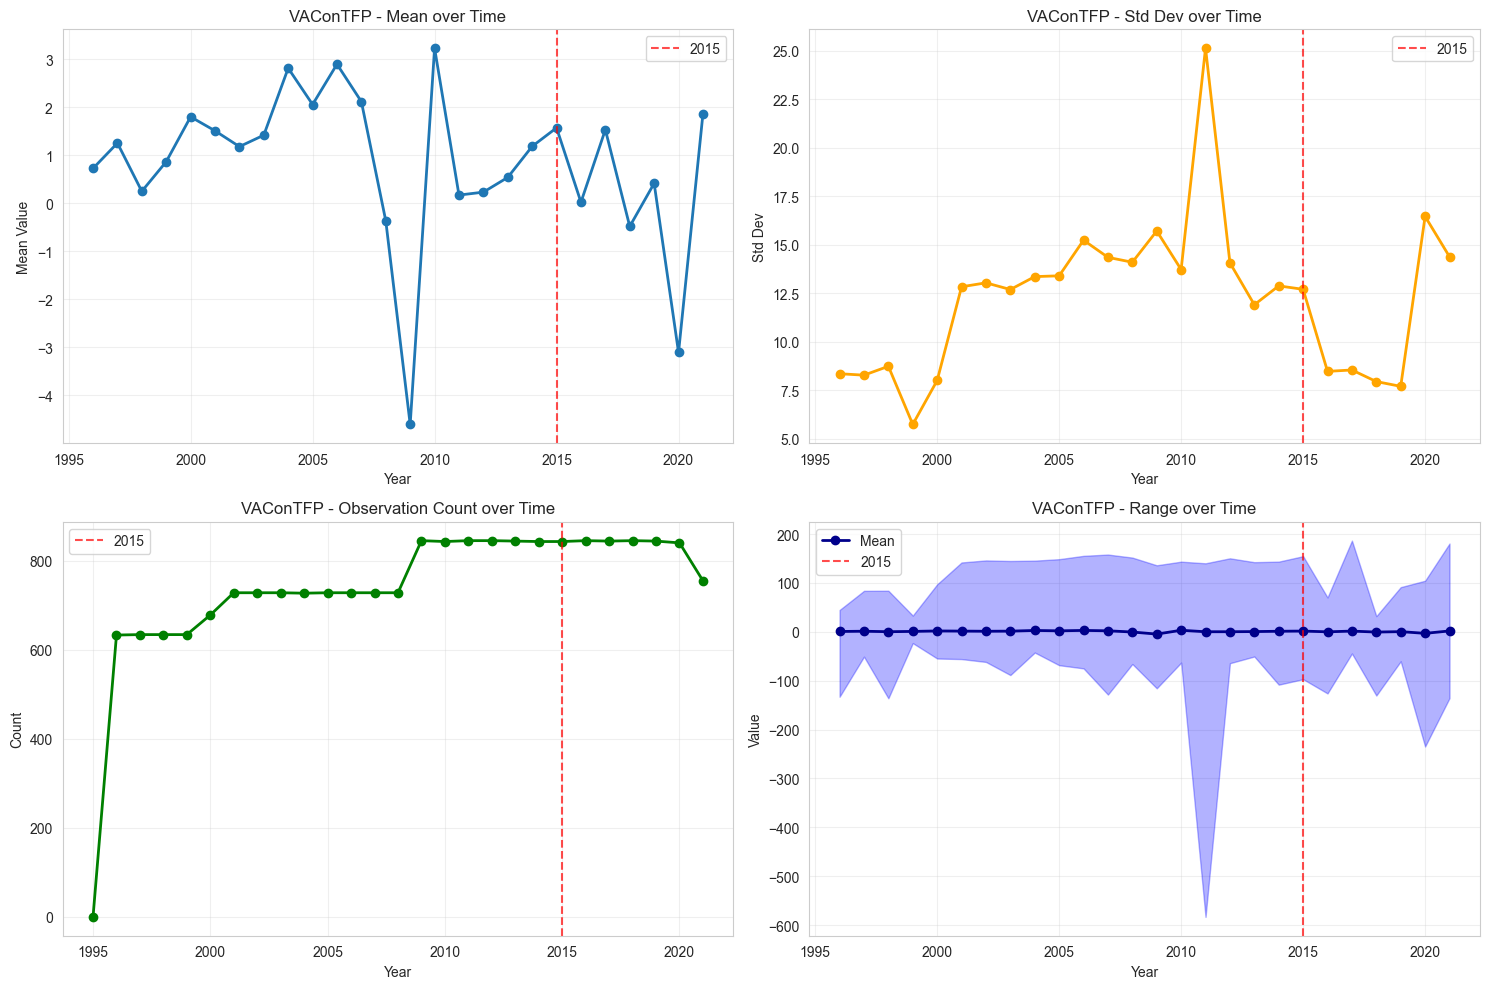

In [ ]:
if tfp_var:
    tfp_data = df[df['var'] == tfp_var].copy()
    
    yearly_stats = tfp_data.groupby('year')['value'].agg(['mean', 'std', 'count', 'min', 'max'])
    yearly_stats['mean_pct_change'] = yearly_stats['mean'].pct_change() * 100
    
    print(f"Yearly statistics for {tfp_var}:")
    print(yearly_stats)
    
    large_changes = yearly_stats[yearly_stats['mean_pct_change'].abs() > 20]
    if len(large_changes) > 0:
        print(f"\nYears with large mean changes (>20%):")
        for year, row in large_changes.iterrows():
            print(f"  {year}: {row['mean_pct_change']:.2f}% change")
    else:
        print(f"\nNo large structural breaks detected (mean changes <20%)")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].plot(yearly_stats.index, yearly_stats['mean'], marker='o', linewidth=2)
    axes[0, 0].axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='2015')
    axes[0, 0].set_title(f'{tfp_var} - Mean over Time')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Mean Value')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(yearly_stats.index, yearly_stats['std'], marker='o', linewidth=2, color='orange')
    axes[0, 1].axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='2015')
    axes[0, 1].set_title(f'{tfp_var} - Std Dev over Time')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Std Dev')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(yearly_stats.index, yearly_stats['count'], marker='o', linewidth=2, color='green')
    axes[1, 0].axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='2015')
    axes[1, 0].set_title(f'{tfp_var} - Observation Count over Time')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].fill_between(yearly_stats.index, yearly_stats['min'], yearly_stats['max'], 
                             alpha=0.3, color='blue')
    axes[1, 1].plot(yearly_stats.index, yearly_stats['mean'], marker='o', linewidth=2, 
                    color='darkblue', label='Mean')
    axes[1, 1].axvline(x=2015, color='red', linestyle='--', alpha=0.7, label='2015')
    axes[1, 1].set_title(f'{tfp_var} - Range over Time')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Value')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No TFP variable available for stability analysis")

## Feasibility Assessment

This section synthesizes findings from the exploratory analysis to evaluate data suitability for the research objectives.

### 1. Productivity Time Series

The primary research objective requires constructing industry-level productivity time series with sufficient temporal span. Adequate consecutive years enable meaningful dynamic analysis.

In [8]:
tfp_available = any(v in df['var'].unique() for v in key_variables['Productivity'])
software_available = any(v in df['var'].unique() for v in key_variables['Software'] + key_variables['ICT Capital'])

print("1. PRODUCTIVITY TIME SERIES\n")

if tfp_available:
    tfp_var = next((v for v in key_variables['Productivity'] if v in df['var'].unique()), None)
    tfp_data = df[df['var'] == tfp_var].copy()
    
    n_countries = tfp_data['geo_code'].nunique()
    n_industries = tfp_data['nace_r2_code'].nunique()
    n_years = tfp_data['year'].nunique()
    year_range = f"{tfp_data['year'].min()}-{tfp_data['year'].max()}"
    
    def check_consecutive(group):
        years = sorted(group['year'].values)
        if len(years) < 2:
            return 0
        max_consecutive = 1
        current_consecutive = 1
        for i in range(1, len(years)):
            if years[i] == years[i-1] + 1:
                current_consecutive += 1
                max_consecutive = max(max_consecutive, current_consecutive)
            else:
                current_consecutive = 1
        return max_consecutive
    
    consecutive_years = tfp_data.groupby(['geo_code', 'nace_r2_code']).apply(
        check_consecutive
    ).reset_index(name='max_consecutive')
    
    good_series = (consecutive_years['max_consecutive'] >= 10).sum()
    
    print(f"Variable available: {tfp_var}")
    print(f"Coverage: {n_countries} countries, {n_industries} industries, {n_years} years ({year_range})")
    print(f"Country-industry combinations with ≥10 consecutive years: {good_series}")
    print(f"Data completeness: {tfp_data['value'].notna().sum() / len(tfp_data) * 100:.1f}%")
else:
    print("No productivity variables found in dataset")

1. PRODUCTIVITY TIME SERIES

Variable available: VAConTFP
Coverage: 34 countries, 58 industries, 27 years (1995-2021)
Country-industry combinations with ≥10 consecutive years: 1972
Data completeness: 37.4%


### 2. AI Intensity Measurement

Software capital variables serve as proxies for AI/technology intensity. Sufficient cross-industry variation enables classification into high and low intensity groups.

In [9]:
print("2. AI INTENSITY MEASUREMENT\n")

if software_available:
    software_var = next((v for v in key_variables['Software'] + key_variables['ICT Capital'] 
                        if v in df['var'].unique()), None)
    software_data = df[df['var'] == software_var].copy()
    
    industry_means = software_data.groupby('nace_r2_code')['value'].mean()
    cv = industry_means.std() / industry_means.mean() if industry_means.mean() != 0 else 0
    
    print(f"Variable available: {software_var}")
    print(f"Industries with data: {software_data['nace_r2_code'].nunique()}")
    print(f"Coefficient of variation across industries: {cv:.3f}")
    print(f"Range: [{industry_means.min():.4f}, {industry_means.max():.4f}]")
else:
    print("No software/ICT variables found in dataset")

print("\n\n3. NETWORK CONSTRUCTION\n")

if tfp_available:
    tfp_var = next((v for v in key_variables['Productivity'] if v in df['var'].unique()), None)
    tfp_data = df[df['var'] == tfp_var].copy()
    
    top_country = tfp_data.groupby('geo_code').size().sort_values(ascending=False).index[0]
    country_tfp = tfp_data[tfp_data['geo_code'] == top_country].copy()
    
    pivot_tfp = country_tfp.pivot_table(index='year', columns='nace_r2_code', values='value')
    min_obs = int(0.5 * len(pivot_tfp))
    pivot_tfp_clean = pivot_tfp.dropna(axis=1, thresh=min_obs)
    
    if pivot_tfp_clean.shape[1] >= 3:
        corr_matrix = pivot_tfp_clean.corr()
        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper_triangle = corr_matrix.where(mask)
        correlations = upper_triangle.stack()
        
        meaningful = ((correlations.abs() >= 0.2) & (correlations.abs() < 0.99)).sum()
        meaningful_pct = meaningful / len(correlations) * 100
        
        print(f"Reference country: {top_country}")
        print(f"Industries in network: {pivot_tfp_clean.shape[1]}")
        print(f"Mean correlation: {correlations.mean():.3f}")
        print(f"Meaningful correlations (0.2 <= |r| < 0.99): {meaningful_pct:.1f}%")
    else:
        print(f"Insufficient industries for network analysis in {top_country}")
else:
    print("No productivity data available")

print("\n\n4. DATA LIMITATIONS\n")

limitations = []

if tfp_available:
    tfp_var = next((v for v in key_variables['Productivity'] if v in df['var'].unique()), None)
    tfp_data = df[df['var'] == tfp_var].copy()
    missing_pct = tfp_data['value'].isna().sum() / len(tfp_data) * 100
    
    if missing_pct > 10:
        limitations.append(f"Missing data: {missing_pct:.1f}% of TFP values are missing")
    
    pre_2015 = tfp_data[tfp_data['year'] < 2015]
    post_2015 = tfp_data[tfp_data['year'] >= 2015]
    
    if len(post_2015) < 0.3 * len(pre_2015):
        limitations.append(f"Temporal imbalance: Post-2015 data is sparse")

missing_vars = [v for v in all_key_vars if v not in df['var'].unique()]
if len(missing_vars) > len(all_key_vars) / 2:
    limitations.append(f"Many key variables missing: {len(missing_vars)}/{len(all_key_vars)}")

if len(limitations) > 0:
    for i, lim in enumerate(limitations, 1):
        print(f"{i}. {lim}")
else:
    print("No major limitations detected")

print("\n\n5. RECOMMENDED COUNTRY SUBSET\n")

if tfp_available:
    country_quality = []
    
    for country in tfp_data['geo_code'].unique():
        country_data = tfp_data[tfp_data['geo_code'] == country]
        
        n_obs = len(country_data)
        n_industries = country_data['nace_r2_code'].nunique()
        n_years = country_data['year'].nunique()
        completeness = country_data['value'].notna().sum() / len(country_data)
        
        quality_score = (n_industries * 0.3 + n_years * 0.3 + 
                        completeness * 100 * 0.2)
        
        country_quality.append({
            'Country': country,
            'Industries': n_industries,
            'Years': n_years,
            'Completeness': f"{completeness*100:.1f}%",
            'Quality Score': quality_score
        })
    
    quality_df = pd.DataFrame(country_quality).sort_values('Quality Score', ascending=False)
    
    print("Top 10 countries by data quality:")
    print(quality_df.head(10).to_string(index=False))
    
    recommended = quality_df.head(5)['Country'].tolist()
    print(f"\nRecommended subset: {', '.join(recommended)}")
else:
    print("Cannot recommend countries without productivity data")

2. AI INTENSITY MEASUREMENT

Variable available: VACon_Soft_DB
Industries with data: 58
Coefficient of variation across industries: 1.091
Range: [0.0127, 0.9828]


3. NETWORK CONSTRUCTION

Reference country: AT
Industries in network: 54
Mean correlation: 0.093
Meaningful correlations (0.2 <= |r| < 0.99): 47.9%


4. DATA LIMITATIONS

1. Missing data: 62.6% of TFP values are missing


5. RECOMMENDED COUNTRY SUBSET

Top 10 countries by data quality:
Country  Industries  Years Completeness  Quality Score
     CZ          58     27        91.1%        43.7248
     DK          58     27        91.1%        43.7120
     AT          58     27        89.7%        43.4310
     FI          58     27        89.6%        43.4183
     SE          58     27        82.9%        42.0773
     FR          58     27        78.0%        41.1066
     NL          58     27        78.0%        41.1066
     DE          58     27        78.0%        41.1066
     IT          58     27        77.8%        41.0556